# 🧠 The Mind of a Model
# Day 8: Model Comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['went_viral'] = df['went_viral'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
df['topic_category'] = le.fit_transform(df['topic_category'])
df['posting_day'] = le.fit_transform(df['posting_day'])

numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Data prepared!')

✅ Data prepared!


/tmp/ipykernel_10027/3617530617.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
X = df.drop(columns=['went_viral'])
y = df['went_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Testing set: {X_test.shape[0]} rows')

Training set: 240 rows
Testing set: 60 rows


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                             eval_metric='logloss',
                             verbosity=0),
    'SVM': SVC(random_state=42, probability=True)
}

print('✅ All models defined!')
print(f'Total models to compare: {len(models)}')

✅ All models defined!
Total models to compare: 5


In [ ]:
results = []

print('TRAINING ALL MODELS:')
print()

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    training_time = round(end - start, 4)
    print(f'✅ {name} trained in {training_time}s')

    results.append({
        'Model': name,
        'Training Time (s)': training_time
    })

TRAINING ALL MODELS:



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression trained in 1.0134s
✅ Decision Tree trained in 0.0149s
✅ Random Forest trained in 0.5182s
✅ XGBoost trained in 0.2753s
✅ SVM trained in 0.0182s


In [ ]:
from sklearn.metrics import precision_score, recall_score

print('EVALUATING ALL MODELS:')
print()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    results[i]['Accuracy'] = round(
        accuracy_score(y_test, y_pred), 4)
    results[i]['Precision'] = round(
        precision_score(y_test, y_pred), 4)
    results[i]['Recall'] = round(
        recall_score(y_test, y_pred), 4)
    results[i]['F1 Score'] = round(
        f1_score(y_test, y_pred), 4)

    print(f'{name}:')
    print(f'  Accuracy  : {results[i]["Accuracy"]:.2%}')
    print(f'  F1 Score  : {results[i]["F1 Score"]:.2%}')
    print()

EVALUATING ALL MODELS:

Logistic Regression:
  Accuracy  : 81.67%
  F1 Score  : 70.27%

Decision Tree:
  Accuracy  : 90.00%
  F1 Score  : 83.33%

Random Forest:
  Accuracy  : 85.00%
  F1 Score  : 72.73%

XGBoost:
  Accuracy  : 88.33%
  F1 Score  : 81.08%

SVM:
  Accuracy  : 66.67%
  F1 Score  : 0.00%



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy',
                                    ascending=False)
results_df = results_df.reset_index(drop=True)

print('MODEL COMPARISON TABLE:')
results_df

MODEL COMPARISON TABLE:


,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.0149,0.9000,0.9375,0.75,0.8333
1,XGBoost,0.2753,0.8833,0.8824,0.75,0.8108
2,Random Forest,0.5182,0.8500,0.9231,0.60,0.7273
3,Logistic Regression,1.0134,0.8167,0.7647,0.65,0.7027
4,SVM,0.0182,0.6667,0.0000,0.00,0.0000


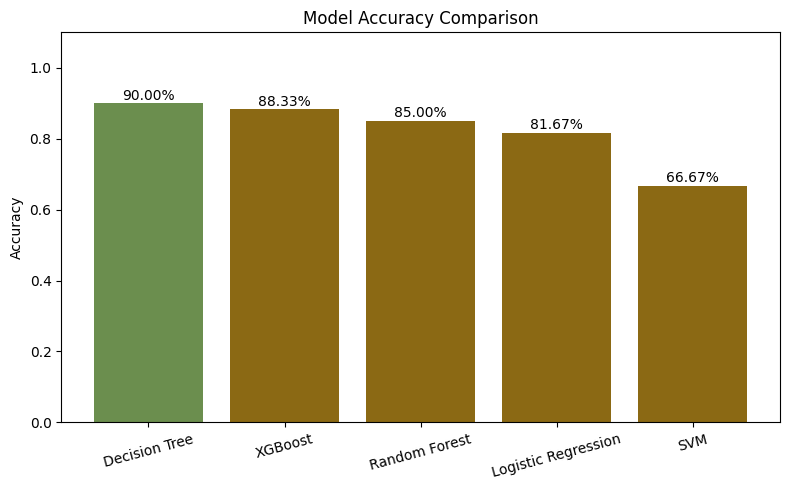

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['#6B8E4E' if i == 0 else '#8B6914'
          for i in range(len(results_df))]

bars = plt.bar(results_df['Model'],
               results_df['Accuracy'],
               color=colors)

for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.2%}',
             ha='center', fontsize=10)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

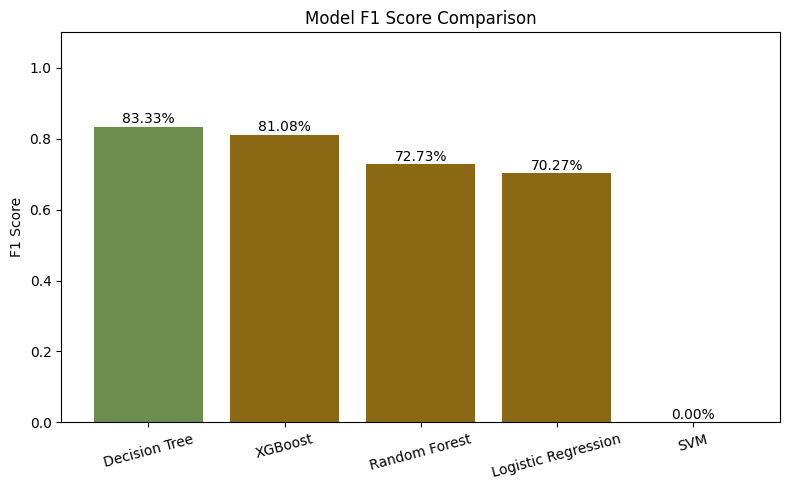

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['#6B8E4E' if i == 0 else '#8B6914'
          for i in range(len(results_df))]

bars = plt.bar(results_df['Model'],
               results_df['F1 Score'],
               color=colors)

for bar, f1 in zip(bars, results_df['F1 Score']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{f1:.2%}',
             ha='center', fontsize=10)

plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
winner = results_df.iloc[0]

print('🏆 BEST MODEL:')
print()
print(f'Model     : {winner["Model"]}')
print(f'Accuracy  : {winner["Accuracy"]:.2%}')
print(f'Precision : {winner["Precision"]:.2%}')
print(f'Recall    : {winner["Recall"]:.2%}')
print(f'F1 Score  : {winner["F1 Score"]:.2%}')
print()
print('This model will be deployed on Day 9.')

🏆 BEST MODEL:

Model     : Decision Tree
Accuracy  : 90.00%
Precision : 93.75%
Recall    : 75.00%
F1 Score  : 83.33%

This model will be deployed on Day 9.
